# PFNet tutorial

This notebook walks through a minimal end-to-end PFNet inference workflow using the example HX-MS dataset.

In this tutorial you will:
1. Run PFNet inference.
2. Inspect the top-level outputs and result fields.
3. Visualize residue-level predictions and export a structure-colored PDB file.
4. Check peptide-level fits against the experimental data.

In [1]:
from pathlib import Path
from pfnet.run_inference import predict

Determination of memory status is not supported on this 
 platform, measuring for memoryleaks will never fail


## Set input and output paths

We start from an HX-MS input file and define an output directory where PFNet will write the JSON results and generated plots.

In [2]:
input_path = Path('../examples/EEHEEEEHEE_rd4_0871.hxms')
output_path = Path('./pfnet_output')
output_path.mkdir(parents=True, exist_ok=True)

input_path, output_path

(PosixPath('../examples/EEHEEEEHEE_rd4_0871.hxms'), PosixPath('pfnet_output'))

## Run PFNet inference

This call runs PFNet on the example dataset. In this notebook, `uptake_plots=True` also saves peptide uptake plots to the output directory for later inspection.

In [3]:
output = predict(
    input=str(input_path),
    output_json=str(output_path / 'pfnet_results.json'),
    centroid_model=False,
    refinement=False,
    uptake_plots=True,
    plots_dir=str(output_path / 'uptake_plots'),
    benchmark=False,
)

loading PFNet model
Number of peptides with experimental max_d: 68
Number of peptides with no experimental max_d: 0
Skipping 0 peptides
plotting uptake plots


## Inspect the top-level output

`predict(...)` returns a dictionary with several layers of output. The top-level keys give access to summary results, analysis objects, reconstructed HDX-MS data objects, and envelope-level error terms.

The cell below shows the main output containers you will use throughout the tutorial. In practice, most downstream work starts from `results`, `analysis_objs`, and `hdxms_data_objs`.

In [4]:
output.keys()

dict_keys(['results', 'analysis_objs', 'hdxms_data_objs', 'AE_pfnet'])

In [5]:
results = output['results']
list(results.keys())

['pfnet_pred_log_kex',
 'pfnet_pred_log_kex_confidence',
 'seq_mask',
 '_benchmark_log_kex',
 'protein_sequence',
 'temperature',
 'pH',
 'saturation',
 'resolution_grouping',
 'resolution_limits',
 'AE_mean_pfnet',
 'AE_median_pfnet',
 'centroid_model']

## Results field guide

The `results` dictionary contains the residue-level predictions together with the metadata needed to interpret them.

- `pfnet_pred_log_kex`: Predicted residue-level `log(kex)` values.
- `pfnet_pred_log_kex_confidence`: Confidence scores in `[0, 1]` for each prediction. Values above about `0.8` are usually considered high-confidence predictions.
- `seq_mask`: Boolean mask for residues excluded from prediction, for example prolines or uncovered residues.
- `protein_sequence`: Input protein sequence.
- `temperature`: Experimental temperature parsed from the input metadata.
- `pH`: Experimental pH(read) parsed from the input metadata.
- `saturation`: D2O saturation setting parsed from the input metadata.
- `resolution_grouping`: Residue groups that share the same resolution segment.
- `resolution_limits`: Encoded resolution boundaries corresponding to `resolution_grouping`.
- `AE_mean_pfnet`: Mean absolute error between the PFNet-reconstructed and experimental isotope envelopes.
- `AE_median_pfnet`: Median absolute error between the PFNet-reconstructed and experimental isotope envelopes.
- `centroid_model`: Indicates whether centroid mode was used for inference.

## Inspect the analysis objects

PFNet also returns a dictionary of analysis objects. These objects expose the residue-level fit, peptide-level raw data, and helper methods for plotting and downstream visualization.

Here we first pull out `analysis_objs` so the later plotting and table-generation steps are easier to read.

In [6]:
analysis_objs = output['analysis_objs']

### Plot residue-level `log(kex)`

The bar plot below summarizes the PFNet residue-level exchange-rate predictions across the sequence.

<Axes: xlabel='Resid', ylabel='-log_kex'>

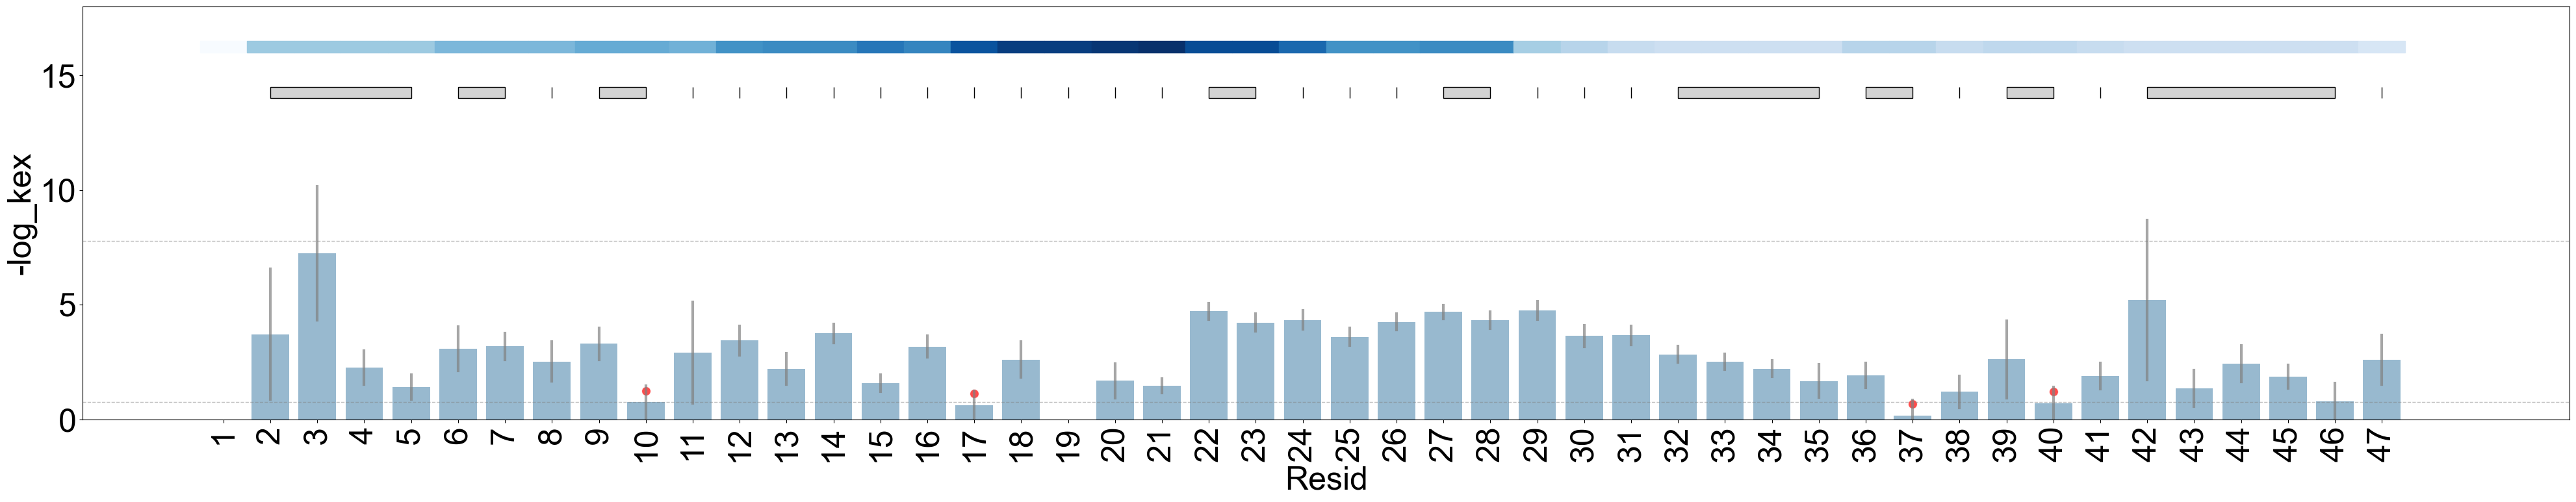

In [9]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(40, 8), sharey=True, sharex=True)

analysis_obj_key = 'analysis_pfnet'
output['analysis_objs']['analysis_pfnet'].plot_kex_bar(
        ax=ax, resolution_indicator_pos=14, show_seq=False, #color="green",
        show_coverage=True
)


### Interpreting non-site-resolved positions

Some residues fall within the same resolution segment. In those cases, multiple residue-level exchange-rate assignments can produce the same reconstructed mass envelope, so the per-residue ordering is not uniquely identifiable from the data alone.

For example, residues 6 and 7 belong to the same resolution segment, and swapping their rates would give an identical envelope fit. The reported average `dG` for such a segment should therefore be interpreted as a segment-level summary rather than a uniquely resolved residue-level value.

In the bar plot, singly resolved residues are marked by a single `|`, while non-site-resolved residues are shown as a gray bar, indicating that their exchange rates are interchangeable within the same resolution segment.

### Convert the prediction to a table

`create_logP_df(...)` generates a residue-wise table that is convenient for inspection or export. It includes the PFNet confidence values alongside the predicted exchange information.

In [11]:
from pfnet.utilts import create_logP_df

In [12]:
df= create_logP_df(output['analysis_objs']['analysis_pfnet'], 
               index_offset=0, 
               pfnet_confidence=results["pfnet_pred_log_kex_confidence"])

In [13]:
df.iloc[5:15]

,resid,resname,avg_dG (kJ/mol),std_dG (kJ/mol),avg_logP (log(sec^-1)),std_logP (log(sec^-1)),log_kch (log(sec^-1)),log_kex (log(sec^-1)),is_nan,coverage,PFNet_confidence,single_resolved,min_pep logPs,min_pep log_kex
5,6,Q,18.401,4.320,3.279,0.770,0.134,-3.145,False,17.0,0.857578,False,"[3.232, 3.326]","[-3.098, -3.192]"
6,7,V,14.136,4.320,2.519,0.770,-0.626,-3.145,False,17.0,0.912098,False,"[2.472, 2.566]","[-3.098, -3.192]"
7,8,H,16.733,4.808,2.981,0.857,0.450,-2.531,False,17.0,0.872234,True,[2.981],[-2.531]
8,9,V,11.033,3.941,1.966,0.702,-0.072,-2.038,False,19.0,0.895162,False,"[3.24, 0.692]","[-3.311, -0.764]"
9,10,D,10.562,3.941,1.882,0.702,-0.156,-2.038,False,19.0,0.892833,False,"[3.155, 0.608]","[-3.311, -0.764]"
10,11,G,14.600,12.372,2.601,2.205,-0.318,-2.920,False,18.0,0.703427,True,[2.601],[-2.92]
11,12,V,15.663,3.560,2.791,0.634,-0.656,-3.447,False,23.0,0.903733,True,[2.791],[-3.447]
12,13,T,10.530,3.823,1.876,0.681,-0.336,-2.212,False,24.0,0.896994,True,[1.876],[-2.212]
13,14,Y,19.987,2.273,3.561,0.405,-0.196,-3.757,False,24.0,0.937424,True,[3.561],[-3.757]
14,15,T,8.063,2.095,1.437,0.373,-0.146,-1.583,False,27.0,0.942184,True,[1.437],[-1.583]


## Map `dG` onto a structure

This step writes a PDB file with PFNet-derived `dG` stored in standard structure fields, so the result can be inspected in external molecular viewers.

In [14]:
from pfnet.plot import BFactorPlot

bfactor_plot = BFactorPlot(
    output["analysis_objs"]['analysis_pfnet'],
    pdb_file=f"../examples/EEHEEEEHEE_rd4_0871.pdb",
    plot_deltaG=True,
    temperature=float(output['results']['temperature']),
)

bfactor_plot.plot(f"{output_path}/PFNet_dG.pdb")

The exported PDB stores `dG` in the B-factor field and PFNet confidence in the occupancy field. You can inspect this file in PyMOL, VS Code extensions, or other structure viewers that expose these attributes.

I made a VS Code extension called [PFNet Viewer](https://marketplace.visualstudio.com/items?itemName=ChenlinLu.pfnet-viewer) to visualize PFNet structure outputs, which is a fork of the original Protein Viewer by Arian Jamasb. 

## Check the fit for specific peptides and timepoints

The reconstructed HDX-MS objects make it possible to compare PFNet predictions against the experimental measurements at the peptide and timepoint level.

The next few cells inspect the reconstructed HDX-MS objects, list available peptide identifiers, and select one peptide for a direct comparison between experiment and PFNet.

In [ ]:
output['hdxms_data_objs']

{'hdxms_data_expt': <pigeon_feather.data.HDXMSData at 0x335507150>,
 'hdxms_data_pfnet': <pigeon_feather.data.HDXMSData at 0x3368ad250>}

In [17]:
all_peptides = output['hdxms_data_objs']['hdxms_data_expt'].states[0].peptides
all_ids = [p.id for p in all_peptides]

In [19]:
all_ids[:10]

['1-7 GSHMTQV',
 '1-10 GSHMTQVHVD',
 '1-11 GSHMTQVHVDG',
 '1-13 GSHMTQVHVDGVT',
 '1-14 GSHMTQVHVDGVTY',
 '1-15 GSHMTQVHVDGVTYT',
 '1-18 GSHMTQVHVDGVTYTFSN',
 '1-21 GSHMTQVHVDGVTYTFSNPEE',
 '1-23 GSHMTQVHVDGVTYTFSNPEEAK',
 '1-24 GSHMTQVHVDGVTYTFSNPEEAKK']

### Compare uptake curves

Here we plot one peptide from both the experimental dataset and the PFNet-reconstructed dataset to compare their uptake behavior across timepoints.

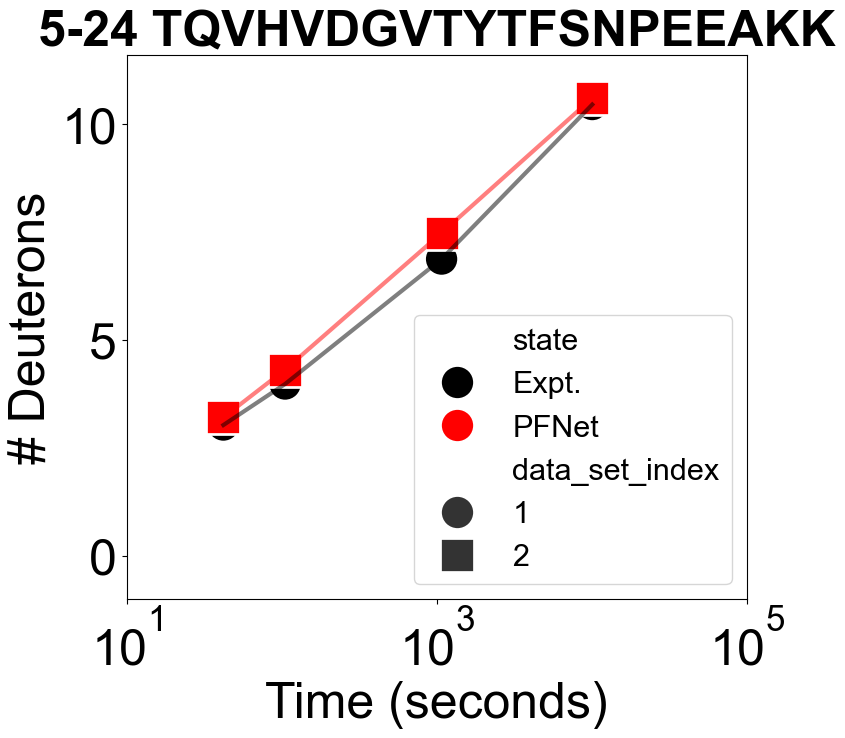

In [29]:
from pigeon_feather.plot import UptakePlot

fig, ax = plt.subplots(1, 1, figsize=(8, 8), sharey=True, sharex=True)

hdxms_data_list = [output['hdxms_data_objs']['hdxms_data_expt'], output['hdxms_data_objs']['hdxms_data_pfnet']]

uptake = UptakePlot(
    hdxms_data_list,
    all_ids[15],
    # states_subset=states_subset,
    if_plot_fit=False,
    figure=fig,
    ax=ax,
    calculate_num_d_from_envelope=True
)

uptake.uptakeplot

### Compare a specific isotope envelope

To inspect the fit more closely, we can group timepoints by peptide identifier and deuteration time, then directly compare the experimental and PFNet-reconstructed isotope envelopes for one matched pair.

In [30]:
from pigeon_feather.tools import group_by_attributes

all_tps = [tp for data in hdxms_data_list for state in data.states for pep in state.peptides for tp in pep.timepoints]
grouped_tps = group_by_attributes(all_tps, ['peptide.identifier', 'deut_time'])

In [31]:
grouped_tps.keys()

dict_keys([('1-7 GSHMTQV', 0.0), ('1-7 GSHMTQV', 46.0), ('1-7 GSHMTQV', 274.0), ('1-7 GSHMTQV', 1574.0), ('1-7 GSHMTQV', 5073.0), ('1-7 GSHMTQV', 15071.0), ('1-7 GSHMTQV', 30071.0), ('1-7 GSHMTQV', 42.0), ('1-7 GSHMTQV', 105.0), ('1-7 GSHMTQV', 1074.0), ('1-7 GSHMTQV', 10073.0), ('1-7 GSHMTQV', 40071.0), ('1-7 GSHMTQV', 60073.0), ('1-7 GSHMTQV', inf), ('1-10 GSHMTQVHVD', 0.0), ('1-10 GSHMTQVHVD', 44.0), ('1-10 GSHMTQVHVD', 248.0), ('1-10 GSHMTQVHVD', 1772.0), ('1-10 GSHMTQVHVD', 14269.0), ('1-10 GSHMTQVHVD', 25072.0), ('1-10 GSHMTQVHVD', 42.0), ('1-10 GSHMTQVHVD', 105.0), ('1-10 GSHMTQVHVD', 1074.0), ('1-10 GSHMTQVHVD', 10073.0), ('1-10 GSHMTQVHVD', 40071.0), ('1-10 GSHMTQVHVD', 60073.0), ('1-10 GSHMTQVHVD', inf), ('1-11 GSHMTQVHVDG', 0.0), ('1-11 GSHMTQVHVDG', 46.0), ('1-11 GSHMTQVHVDG', 274.0), ('1-11 GSHMTQVHVDG', 1574.0), ('1-11 GSHMTQVHVDG', 5073.0), ('1-11 GSHMTQVHVDG', 15071.0), ('1-11 GSHMTQVHVDG', 42.0), ('1-11 GSHMTQVHVDG', 105.0), ('1-11 GSHMTQVHVDG', 1074.0), ('1-11 GSHMTQV

Text(0, 0.5, 'probability')

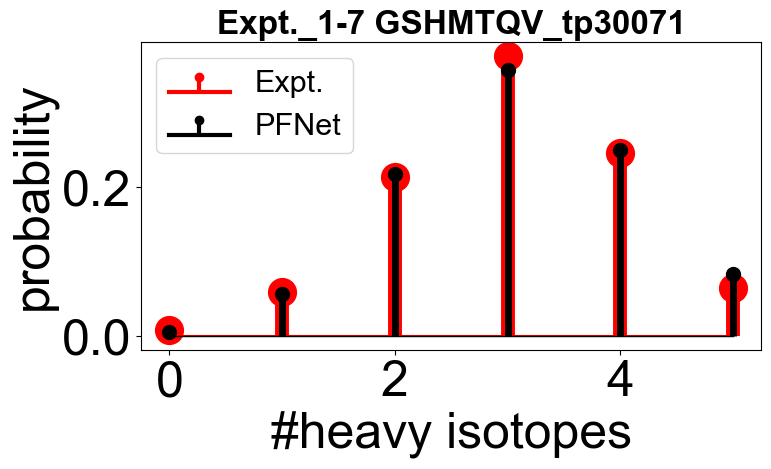

In [ ]:
tp_pair = grouped_tps[('1-7 GSHMTQV', 30071.0)]
tp_pair_expt = [tp for tp in tp_pair if tp.peptide.protein_state.state_name == 'Expt.'][0]
tp_pair_pfnet = [tp for tp in tp_pair if tp.peptide.protein_state.state_name == 'PFNet'][0]


fig, ax = plt.subplots(1, 1, figsize=(8, 4))

peak_num = np.where(tp_pair_expt.isotope_envelope>1e-6)[0][-1]

stem1 = plt.stem(tp_pair_expt.isotope_envelope[:peak_num], linefmt='r-', markerfmt='ro', basefmt='r-', label='Expt.')
stem2 = plt.stem(tp_pair_pfnet.isotope_envelope[:peak_num], linefmt='k-', markerfmt='ko', basefmt='k-', label='PFNet')
plt.legend()


title  =  f'{tp_pair_expt.peptide.protein_state.state_name}_{tp_pair_expt.peptide.identifier}_tp{int(tp_pair_expt.deut_time)}'
plt.title(title, fontdict={'fontsize': 24})
    
plt.setp(stem1[1], linewidth = 10,)
plt.setp(stem1[0], markersize = 20)
plt.setp(stem1[2], linewidth = 1.5)


plt.setp(stem2[1], linewidth = 5)
plt.setp(stem2[0], markersize = 10)
plt.setp(stem2[2], linewidth = 1)

plt.xlabel('#heavy isotopes')
plt.ylabel('Probability')


## Summary

At this point, you have run PFNet inference, inspected the residue-level outputs, exported a structure-colored PDB file, and checked peptide-level agreement between the PFNet reconstruction and the experimental data. This workflow is usually a good starting point before moving on to deeper residue interpretation or structure-based analysis.